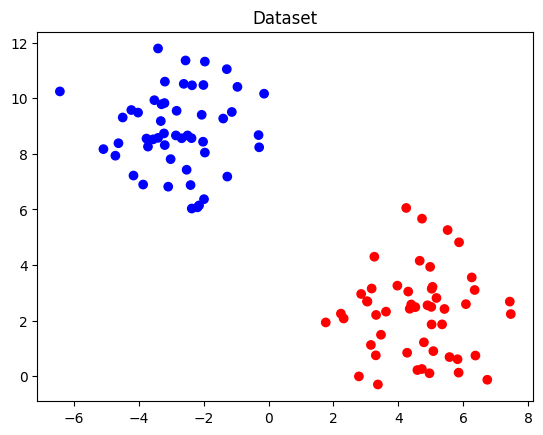

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generar datos
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.5)

# Convertir etiquetas a 0 y 1 (si hace falta)
y = np.where(y == 0, 0, 1)

# Visualizar
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.title("Dataset")
plt.show()

In [3]:
class Perceptron:
    def __init__(self, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors = []

    def activation(self, x):
        return np.where(x >= 0, 1, 0)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)

    def train(self, X, y):
        n_samples, n_features = X.shape

        # Inicialización
        self.weights = np.random.randn(n_features)
        self.bias = 0

        for epoch in range(self.epochs):
            errors = 0

            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = self.activation(linear_output)

                update = self.lr * (y[i] - y_pred)

                self.weights += update * X[i]
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)

In [4]:
model = Perceptron(lr=0.01, epochs=50)
model.train(X, y)

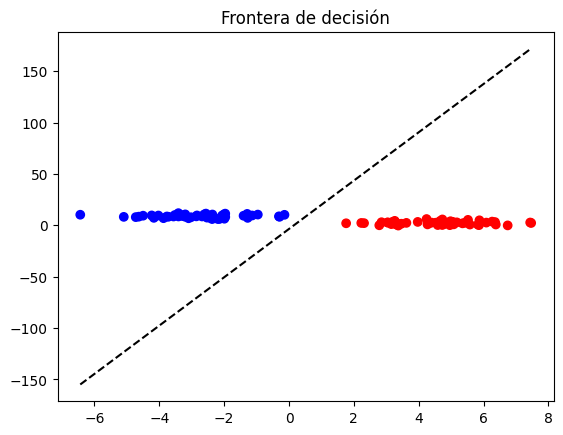

In [5]:
def plot_decision_boundary(X, y, model):
    x1 = np.linspace(X[:,0].min(), X[:,0].max(), 100)

    # w1*x1 + w2*x2 + b = 0 → despejo x2
    x2 = -(model.weights[0] * x1 + model.bias) / model.weights[1]

    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
    plt.plot(x1, x2, 'k--')
    plt.title("Frontera de decisión")
    plt.show()

plot_decision_boundary(X, y, model)

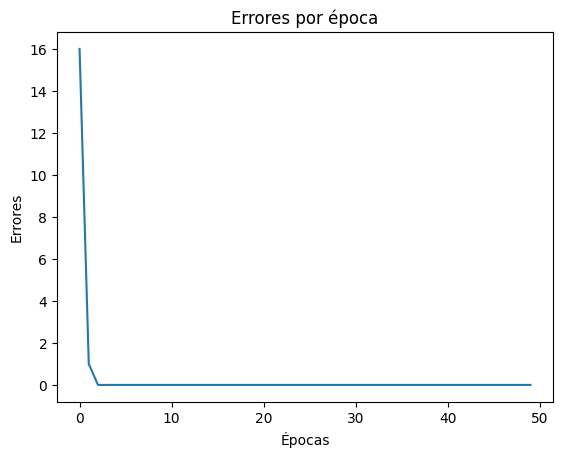

In [6]:
plt.plot(model.errors)
plt.title("Errores por época")
plt.xlabel("Épocas")
plt.ylabel("Errores")
plt.show()

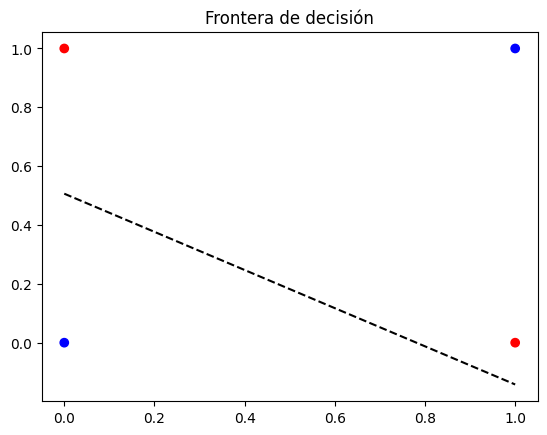

In [7]:
X_xor = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_xor = np.array([0,1,1,0])

model = Perceptron(lr=0.1, epochs=20)
model.train(X_xor, y_xor)

plot_decision_boundary(X_xor, y_xor, model)

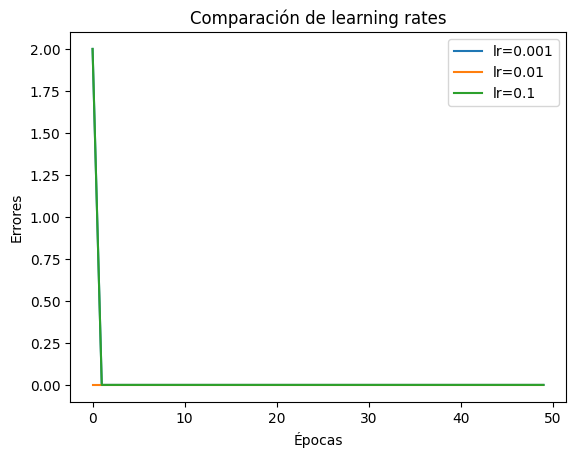

In [8]:

lrs = [0.001, 0.01, 0.1]

for lr in lrs:
    model = Perceptron(lr=lr, epochs=50)
    model.train(X, y)

    plt.plot(model.errors, label=f"lr={lr}")

plt.legend()
plt.title("Comparación de learning rates")
plt.xlabel("Épocas")
plt.ylabel("Errores")
plt.show()

## Respuestas

### ¿Por qué el perceptrón no puede resolver XOR?

El perceptrón no puede resolver el problema XOR porque este no es linealmente separable.  
Esto significa que no existe una única recta que pueda separar correctamente las dos clases.

En el caso de XOR:
- Los puntos de una clase están en (0,1) y (1,0)  
- Los de la otra están en (0,0) y (1,1)  

Estos puntos están distribuidos de forma diagonal, por lo que cualquier línea que se trace va a clasificar mal al menos uno de los puntos.

El perceptrón solo puede aprender fronteras de decisión lineales, por eso falla en este caso.


### Dibujar el caso XOR

El gráfico de XOR muestra que los puntos están “cruzados”, lo que impide separarlos con una recta.  
Esto confirma visualmente que el problema no es linealmente separable.


### ¿Qué pasa si cambiamos el learning rate?

Al probar distintos valores de learning rate:

- Con un valor bajo (ej: 0.001):  
  El modelo aprende lentamente y necesita más épocas para converger.

- Con un valor medio (ej: 0.01):  
  El aprendizaje es más equilibrado y converge de forma estable.

- Con un valor alto (ej: 0.1):  
  El modelo puede volverse inestable y puede “saltar” la solución óptima, dificultando la convergencia.

### ¿Cuántas épocas necesitó para converger? ¿De qué depende?

La cantidad de épocas necesarias para converger depende de varios factores:

- El learning rate  
- La distribución de los datos  
- Si los datos son linealmente separables o no  

En datos linealmente separables, el perceptrón suele converger en una cantidad finita de épocas.  
En cambio, en datos no linealmente separables (como XOR), el modelo no converge completamente y el error nunca llega a cero.